In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('/content/diabetes_diagnosed_clean_data.csv')

In [ ]:
df_test=pd.read_csv('/content/diabetes_test_clean_data.csv')

In [ ]:
X_train = df.drop("diagnosed_diabetes", axis=1)
y_train = df["diagnosed_diabetes"]

In [ ]:
X_test = df_test.copy()

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [ ]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

In [ ]:
rank_cat=['education_level','income_level']
un_rank_cat=['gender','ethnicity','smoking_status','employment_status']

In [ ]:
pd.set_option('display.max_columns', None)

In [ ]:
df.shape

(700000, 23)

In [ ]:
df_test.shape

(300000, 22)

In [ ]:
X_test.shape

(300000, 22)

In [ ]:
X_train.shape

(700000, 22)

In [ ]:
y_train.shape

(700000,)

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train)

In [ ]:
from lightgbm import LGBMClassifier

lgbm_clf = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=10,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary",
    random_state=42,
    n_jobs=-1
)

In [ ]:
from sklearn.preprocessing import FunctionTransformer

In [ ]:
log_transform=FunctionTransformer(np.log1p,validate=False)

In [ ]:
transform_cols=['age', 'physical_activity_minutes_per_week', 'diet_score','bmi', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides']

In [ ]:
pipe_2=Pipeline([
   ('CL',ColumnTransformer([
       ('f_t',log_transform,transform_cols),
       ('cat',OneHotEncoder(drop='first'),un_rank_cat),
       ('rank',OrdinalEncoder(),rank_cat)
   ])),
  ('model',lgbm_clf )
])

In [ ]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

In [ ]:
my_cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

In [ ]:
param_dist_xgb = {
    "model__n_estimators": [450, 500, 600,550],
    "model__max_depth": [ 8, 10,12],
    "model__learning_rate": [0.01, 0.05,0.07, 0.1],
    "model__subsample": [0.7, 0.8, 0.9,1.0],
    "model__colsample_bytree": [0.7, 0.8,0.9, 1.0]
}

In [ ]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

In [ ]:
search_xgb = RandomizedSearchCV(
    pipe_2,
    param_distributions=param_dist_xgb,
    n_iter=35,
    scoring=scoring,
    cv=my_cv,
    refit="accuracy",
    random_state=42,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)


In [ ]:
import lightgbm as lgb

In [ ]:
preprocessor_step = pipe_2.named_steps['CL']
preprocessor_step.fit(X_train)
X_val_transformed = preprocessor_step.transform(X_val)

fit_params = {
    "model__eval_set": [(X_val_transformed, y_val)],
    "model__callbacks": [lgb.early_stopping(40, verbose=False)]
}

In [ ]:
search_xgb.fit(X_train, y_train, **fit_params)

Fitting 3 folds for each of 35 candidates, totalling 105 fits
[LightGBM] [Info] Number of positive: 436307, number of negative: 263693
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.334082 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1397
[LightGBM] [Info] Number of data points in the train set: 700000, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.623296 -> initscore=0.503561
[LightGBM] [Info] Start training from score 0.503561


RandomizedSearchCV(cv=StratifiedKFold(n_splits=3, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('CL',
                                              ColumnTransformer(transformers=[('f_t',
                                                                               FunctionTransformer(func=<ufunc 'log1p'>),
                                                                               ['age',
                                                                                'physical_activity_minutes_per_week',
                                                                                'diet_score',
                                                                                'bmi',
                                                                                'systolic_bp',
                                                                                'diastolic_bp',
                                                                                'heart_rate',
                                                                                'cholesterol_total',
                                                                                'hdl_cholesterol',
                                                                                'ldl_cholesterol...
                   param_distributions={'model__colsample_bytree': [0.7, 0.8,
                                                                    0.9, 1.0],
                                        'model__learning_rate': [0.01, 0.05,
                                                                 0.07, 0.1],
                                        'model__max_depth': [8, 10, 12],
                                        'model__n_estimators': [450, 500, 600,
                                                                550],
                                        'model__subsample': [0.7, 0.8, 0.9,
                                                             1.0]},
                   random_state=42, refit='accuracy', return_train_score=True,
                   scoring={'accuracy': 'accuracy', 'f1': 'f1',
                            'precision': 'precision', 'recall': 'recall'},
                   verbose=1)

In [ ]:
best_pipe = search_xgb.best_estimator_

In [ ]:
best_pipe

Pipeline(steps=[('CL',
                 ColumnTransformer(transformers=[('f_t',
                                                  FunctionTransformer(func=<ufunc 'log1p'>),
                                                  ['age',
                                                   'physical_activity_minutes_per_week',
                                                   'diet_score', 'bmi',
                                                   'systolic_bp',
                                                   'diastolic_bp', 'heart_rate',
                                                   'cholesterol_total',
                                                   'hdl_cholesterol',
                                                   'ldl_cholesterol',
                                                   'triglycerides']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['gender', 'ethnicity',
                                                   'smoking_status',
                                                   'employment_status']),
                                                 ('rank', OrdinalEncoder(),
                                                  ['education_level',
                                                   'income_level'])])),
                ('model',
                 LGBMClassifier(colsample_bytree=0.7, max_depth=8,
                                n_estimators=500, n_jobs=-1, objective='binary',
                                random_state=42, subsample=0.7))])

In [ ]:
from joblib import dump, load

In [ ]:
loaded_pipe = load('/content/best_lightgbm_pipeline.joblib')

In [ ]:
search_xgb.cv_results_

In [ ]:
y_test_pred = best_pipe.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


# **Save Pipeline**

In [ ]:
import joblib

joblib.dump(best_pipe, 'best_lightgbm_pipeline.joblib')
print("Pipeline saved successfully as 'best_lightgbm_pipeline.joblib'")

Pipeline saved successfully as 'best_lightgbm_pipeline.joblib'


.

.

.

## **Optuna**

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 8.0 MB/s eta 0:00:00


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate
import optuna

kf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)


def objective(trial):
    # Hyperparameters to tune
    n_estimators = trial.suggest_categorical('model__n_estimators', [450, 500, 520, 550])
    max_depth = trial.suggest_categorical('model__max_depth', [8, 10, 12])
    learning_rate = trial.suggest_categorical('model__learning_rate', [0.01, 0.05, 0.02, 0.03])
    subsample = trial.suggest_categorical('model__subsample', [0.7, 0.8, 0.9, 1.0])
    colsample_bytree = trial.suggest_categorical('model__colsample_bytree', [0.7, 0.8, 0.9, 1.0])

    # Set hyperparameters in pipeline
    # The model step in pipe_2 is named 'model'
    pipe_2.set_params(
        model__n_estimators=n_estimators,
        model__max_depth=max_depth,
        model__learning_rate=learning_rate,
        model__subsample=subsample,
        model__colsample_bytree=colsample_bytree
    )

    # Cross-validation score
    scores = cross_validate(
        pipe_2,
        X_train,
        y_train,
        cv=kf,
        scoring='accuracy',
        return_train_score=True,
        n_jobs=-1
    )

    # store BOTH
    trial.set_user_attr("train_accuracy", scores["train_score"].mean())
    trial.set_user_attr("val_accuracy", scores["test_score"].mean())

    # optimize validation accuracy
    return scores["test_score"].mean()

# **Run Optuna Study**

In [ ]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=35)

[I 2026-01-23 04:04:02,728] A new study created in memory with name: no-name-82f4cb90-d85a-4348-9baf-aa16d5aae956
[I 2026-01-23 04:07:48,469] Trial 0 finished with value: 0.6672642845231334 and parameters: {'model__n_estimators': 520, 'model__max_depth': 8, 'model__learning_rate': 0.03, 'model__subsample': 1.0, 'model__colsample_bytree': 1.0}. Best is trial 0 with value: 0.6672642845231334.
[I 2026-01-23 04:12:14,950] Trial 1 finished with value: 0.6672999983394607 and parameters: {'model__n_estimators': 550, 'model__max_depth': 12, 'model__learning_rate': 0.02, 'model__subsample': 0.8, 'model__colsample_bytree': 0.7}. Best is trial 1 with value: 0.6672999983394607.
[I 2026-01-23 04:15:58,073] Trial 2 finished with value: 0.6656528558965963 and parameters: {'model__n_estimators': 500, 'model__max_depth': 8, 'model__learning_rate': 0.02, 'model__subsample': 1.0, 'model__colsample_bytree': 1.0}. Best is trial 1 with value: 0.6672999983394607.
[I 2026-01-23 04:20:48,406] Trial 3 finished 

# **Results**

In [ ]:
print(study.trials)

[FrozenTrial(number=0, state=<TrialState.COMPLETE: 1>, values=[0.6672642845231334], datetime_start=datetime.datetime(2026, 1, 23, 4, 4, 2, 731374), datetime_complete=datetime.datetime(2026, 1, 23, 4, 7, 48, 469319), params={'model__n_estimators': 520, 'model__max_depth': 8, 'model__learning_rate': 0.03, 'model__subsample': 1.0, 'model__colsample_bytree': 1.0}, user_attrs={'train_accuracy': np.float64(0.6725607140267065), 'val_accuracy': np.float64(0.6672642845231334)}, system_attrs={}, intermediate_values={}, distributions={'model__n_estimators': CategoricalDistribution(choices=(450, 500, 520, 550)), 'model__max_depth': CategoricalDistribution(choices=(8, 10, 12)), 'model__learning_rate': CategoricalDistribution(choices=(0.01, 0.05, 0.02, 0.03)), 'model__subsample': CategoricalDistribution(choices=(0.7, 0.8, 0.9, 1.0)), 'model__colsample_bytree': CategoricalDistribution(choices=(0.7, 0.8, 0.9, 1.0))}, trial_id=0, value=None), FrozenTrial(number=1, state=<TrialState.COMPLETE: 1>, values

In [ ]:
study.best_trial

FrozenTrial(number=18, state=<TrialState.COMPLETE: 1>, values=[0.6691057131721204], datetime_start=datetime.datetime(2026, 1, 23, 5, 8, 4, 446791), datetime_complete=datetime.datetime(2026, 1, 23, 5, 11, 43, 179013), params={'model__n_estimators': 550, 'model__max_depth': 10, 'model__learning_rate': 0.05, 'model__subsample': 0.7, 'model__colsample_bytree': 0.9}, user_attrs={'train_accuracy': np.float64(0.6781685711711001), 'val_accuracy': np.float64(0.6691057131721204)}, system_attrs={}, intermediate_values={}, distributions={'model__n_estimators': CategoricalDistribution(choices=(450, 500, 520, 550)), 'model__max_depth': CategoricalDistribution(choices=(8, 10, 12)), 'model__learning_rate': CategoricalDistribution(choices=(0.01, 0.05, 0.02, 0.03)), 'model__subsample': CategoricalDistribution(choices=(0.7, 0.8, 0.9, 1.0)), 'model__colsample_bytree': CategoricalDistribution(choices=(0.7, 0.8, 0.9, 1.0))}, trial_id=18, value=None)

In [ ]:
print(study.best_params)

{'model__n_estimators': 550, 'model__max_depth': 10, 'model__learning_rate': 0.05, 'model__subsample': 0.7, 'model__colsample_bytree': 0.9}


In [ ]:
study.best_trial.user_attrs

{'train_accuracy': np.float64(0.6781685711711001),
 'val_accuracy': np.float64(0.6691057131721204)}

In [ ]:
print("Best value (val accuracy):", study.best_value)
print("Best params:", study.best_params)
print("Train accuracy:", study.best_trial.user_attrs["train_accuracy"])
print("Validation accuracy:", study.best_trial.user_attrs["val_accuracy"])


Best value (val accuracy): 0.6691057131721204
Best params: {'model__n_estimators': 550, 'model__max_depth': 10, 'model__learning_rate': 0.05, 'model__subsample': 0.7, 'model__colsample_bytree': 0.9}
Train accuracy: 0.6781685711711001
Validation accuracy: 0.6691057131721204


In [ ]:
df = study.trials_dataframe()

print(df[[
    "number",
    "value",
    "user_attrs_train_accuracy",
    "user_attrs_val_accuracy"
]])


    number     value  user_attrs_train_accuracy  user_attrs_val_accuracy
0        0  0.667264                   0.672561                 0.667264
1        1  0.667300                   0.670663                 0.667300
2        2  0.665653                   0.669316                 0.665653
3        3  0.663826                   0.665955                 0.663826
4        4  0.667769                   0.672692                 0.667769
5        5  0.662016                   0.663922                 0.662016
6        6  0.663634                   0.665529                 0.663634
7        7  0.667549                   0.671758                 0.667549
8        8  0.665793                   0.668779                 0.665793
9        9  0.667326                   0.671796                 0.667326
10      10  0.668957                   0.677629                 0.668957
11      11  0.668957                   0.677629                 0.668957
12      12  0.668957                   0.677629    

In [ ]:
best_optuna_params = study.best_params

best_optuna_pipe = pipe_2
best_optuna_pipe.set_params(**best_optuna_params)

best_optuna_pipe.fit(X_train, y_train)

import joblib
joblib.dump(best_optuna_pipe, 'best_optuna_lightgbm_pipeline.joblib')
print("Optuna-tuned pipeline saved successfully as 'best_optuna_lightgbm_pipeline.joblib'")

[LightGBM] [Info] Number of positive: 436307, number of negative: 263693
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.072608 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1397
[LightGBM] [Info] Number of data points in the train set: 700000, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.623296 -> initscore=0.503561
[LightGBM] [Info] Start training from score 0.503561
Optuna-tuned pipeline saved successfully as 'best_optuna_lightgbm_pipeline.joblib'


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


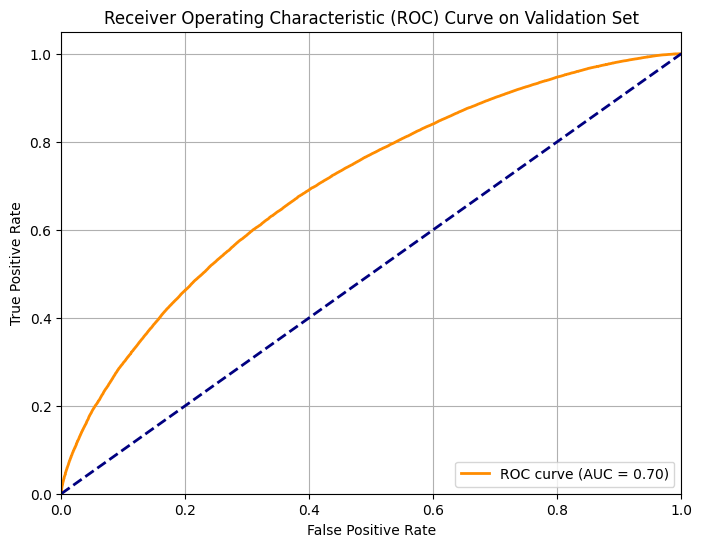

ROC AUC Score on Validation Set: 0.7024


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_val_pred_proba = best_optuna_pipe.predict_proba(X_val)[:, 1]

fpr, tpr, thresholds = roc_curve(y_val, y_val_pred_proba)

roc_auc = roc_auc_score(y_val, y_val_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve on Validation Set')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"ROC AUC Score on Validation Set: {roc_auc:.4f}")

In [ ]:
from sklearn.metrics import log_loss

logloss = log_loss(y_val, y_val_pred_proba)
print(f"Log Loss on Validation Set: {logloss:.4f}")

Log Loss on Validation Set: 0.6001


In [ ]:
from sklearn.metrics import precision_recall_curve, f1_score, accuracy_score
import numpy as np

y_val_pred_proba = best_optuna_pipe.predict_proba(X_val)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_val, y_val_pred_proba)

f1_scores = (2 * precisions * recalls) / (precisions + recalls)
f1_scores = np.nan_to_num(f1_scores)

optimal_threshold_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_threshold_idx]

y_val_pred_optimal = (y_val_pred_proba >= optimal_threshold).astype(int)

print(f"Optimal Threshold (maximizing F1-score): {optimal_threshold:.4f}")
print(f"Accuracy with optimal threshold: {accuracy_score(y_val, y_val_pred_optimal):.4f}")
print(f"F1-score with optimal threshold: {f1_score(y_val, y_val_pred_optimal):.4f}")


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Optimal Threshold (maximizing F1-score): 0.4122
Accuracy with optimal threshold: 0.6627
F1-score with optimal threshold: 0.7795
